# Step 5: Tokenizer-aware length analysis
Here we pick MuRIL and tokenize the full text column to find the ideal `max_length`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer


In [2]:
# Load full data
df = pd.read_csv("data/data.csv").dropna(subset=['text'])

# Load Tokenizer (MuRIL)
model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


In [3]:
# Tokenize and get lengths
def get_token_length(text):
    # .encode gives the token IDs (including special tokens [CLS] and [SEP])
    return len(tokenizer.encode(str(text), add_special_tokens=True))

print("Tokenizing all texts... This may take a minute.")
df['token_length'] = df['text'].apply(get_token_length)


Token indices sequence length is longer than the specified maximum sequence length for this model (554 > 512). Running this sequence through the model will result in indexing errors


Tokenizing all texts... This may take a minute.


count    17123.000000
mean       157.206039
std        186.870135
min          3.000000
50%         48.000000
90%        470.800000
95%        532.000000
99%        593.780000
max       2234.000000
Name: token_length, dtype: float64


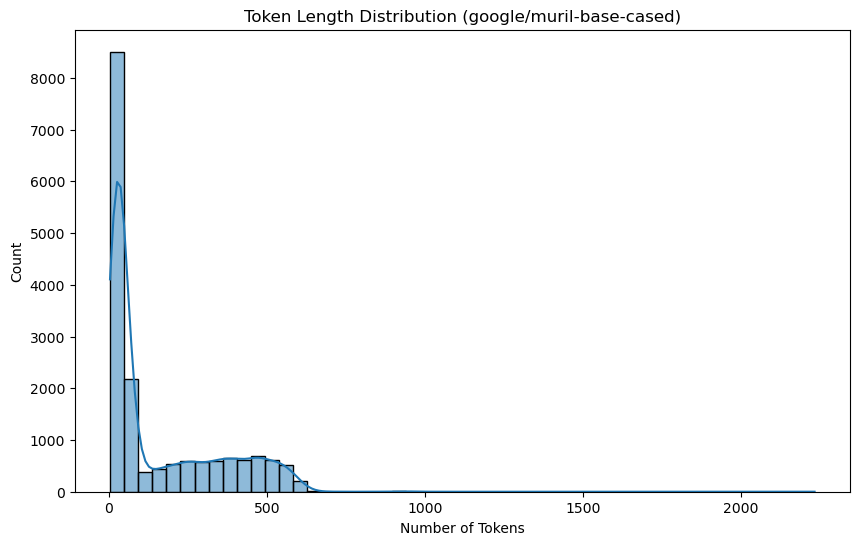

In [4]:
# Stats
desc = df['token_length'].describe(percentiles=[0.9, 0.95, 0.99])
print(desc)

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['token_length'], bins=50, kde=True)
plt.title(f'Token Length Distribution ({model_name})')
plt.xlabel('Number of Tokens')
plt.show()


In [5]:
# Truncation Analysis
truncated_256 = (df['token_length'] > 256).sum()
truncated_512 = (df['token_length'] > 512).sum()
total = len(df)

print(f"Samples truncated at 256 tokens: {truncated_256} ({(truncated_256/total)*100:.2f}%)")
print(f"Samples truncated at 512 tokens: {truncated_512} ({(truncated_512/total)*100:.2f}%)")


Samples truncated at 256 tokens: 4674 (27.30%)
Samples truncated at 512 tokens: 1111 (6.49%)
